# Alpha-Thalassemia Carrier Detection Using Machine Learning

### Objective

The aim of this project is to develop a simple machine learning model that can differentiate between:

- Normal individuals
- Alpha-thalassemia carriers

The model will use blood test measurements such as haemoglobin, RBC count, MCV, MCH, MCHC, RDW and haemoglobin variants.

The project follows these steps:

1. Load and understand the dataset
2. Clean the data
3. Explore the data
4. Prepare the data for machine learning
5. Train a Logistic Regression model
6. Evaluate the model
7. Interpret the results

## 1. Importing Libraries

We first import the Python libraries required for the project.

- Pandas is used to work with the dataset.
- NumPy is used for numerical calculations.
- Matplotlib and Seaborn are used for graphs.
- Scikit-learn is used to build and evaluate the machine learning model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Loading the Dataset

The dataset contains blood test measurements of individuals classified as either normal or alpha-thalassemia carriers.

In [3]:
data = pd.read_csv("alphanorm.csv")

data.head()

,sex,hb,pcv,rbc,mcv,mch,mchc,rdw,wbc,neut,lymph,plt,hba,hba2,hbf,phenotype
0,female,10.8,35.2,5.12,68.7,21.2,30.8,13.4,9.6,53.0,33.0,309.0,88.5,2.6,0.11,alpha carrier
1,male,10.8,26.6,4.28,62.1,25.3,40.8,19.8,10.3,49.4,43.1,687.0,87.8,2.4,0.90,alpha carrier
2,female,10.8,35.2,5.12,68.7,21.2,30.8,13.4,9.6,53.0,33.0,309.0,88.5,2.6,0.10,alpha carrier
3,male,14.5,43.5,5.17,84.0,28.0,33.4,12.1,11.9,31.0,50.0,334.0,86.8,2.8,0.30,alpha carrier
4,male,11.5,34.4,5.02,68.7,22.9,33.4,15.7,20.4,67.0,30.0,596.0,86.3,2.4,1.30,alpha carrier


## 3. Understanding the Dataset

Before building a machine learning model, we need to understand the structure of the dataset.

We will check:

- Number of rows and columns
- Column names
- Data types
- Basic statistical information

In [4]:
print("Number of rows and columns:", data.shape)

Number of rows and columns: (203, 16)


In [5]:
data.info()
data.describe()
data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sex        203 non-null    object 
 1   hb         203 non-null    float64
 2   pcv        203 non-null    float64
 3   rbc        202 non-null    float64
 4   mcv        203 non-null    float64
 5   mch        201 non-null    float64
 6   mchc       203 non-null    float64
 7   rdw        203 non-null    float64
 8   wbc        203 non-null    float64
 9   neut       203 non-null    float64
 10  lymph      203 non-null    float64
 11  plt        203 non-null    float64
 12  hba        203 non-null    float64
 13  hba2       203 non-null    float64
 14  hbf        203 non-null    float64
 15  phenotype  203 non-null    object 
dtypes: float64(14), object(2)
memory usage: 25.5+ KB


Index(['sex', 'hb', 'pcv', 'rbc', 'mcv', 'mch', 'mchc', 'rdw', 'wbc', 'neut',
       'lymph', 'plt', 'hba', 'hba2', 'hbf', 'phenotype'],
      dtype='object')

## 4. Checking the Target Variable

The column `phenotype` is our target variable.

It contains two groups:

- normal
- alpha carrier

Our machine learning model will learn to predict this variable.

In [6]:
data["phenotype"].value_counts()

,count
phenotype,
alpha carrier,148
normal,55


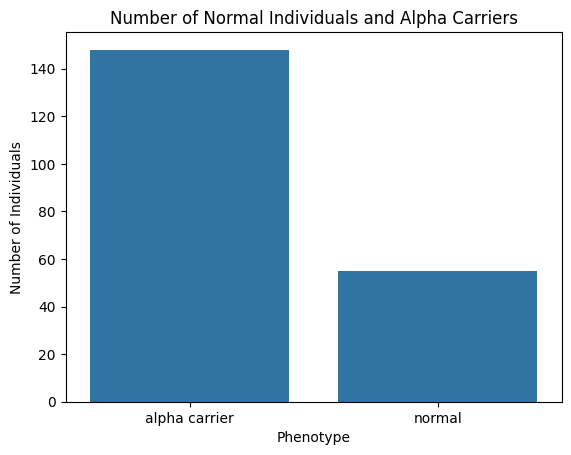

In [7]:
sns.countplot(x="phenotype", data=data)

plt.title("Number of Normal Individuals and Alpha Carriers")
plt.xlabel("Phenotype")
plt.ylabel("Number of Individuals")
plt.show()

## 5. Checking for Missing Values

Missing values can cause problems when training a machine learning model.

Therefore, we first check whether any values are missing.

In [8]:
data.isnull().sum()

,0
sex,0
hb,0
pcv,0
rbc,1
mcv,0
mch,2
mchc,0
rdw,0
wbc,0
neut,0


### Handling Missing Values

For the numerical columns with missing values, we will replace the missing observations with the median of that column.

The median is useful because it is less affected by unusually large or small values.

In [9]:
data = data.fillna(data.median(numeric_only=True))

In [10]:
data.isnull().sum()

,0
sex,0
hb,0
pcv,0
rbc,0
mcv,0
mch,0
mchc,0
rdw,0
wbc,0
neut,0


## 6. Exploring the Blood Measurements

Before training the model, it is useful to see whether some blood measurements look different between normal individuals and alpha-thalassemia carriers.

We will look at a few important variables such as:

- Haemoglobin
- RBC
- MCV
- MCH
- HbA2

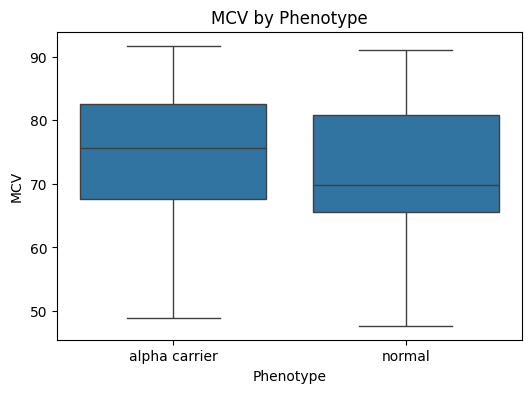

In [11]:
plt.figure(figsize=(6, 4))

sns.boxplot(x="phenotype", y="mcv", data=data)

plt.title("MCV by Phenotype")
plt.xlabel("Phenotype")
plt.ylabel("MCV")

plt.show()

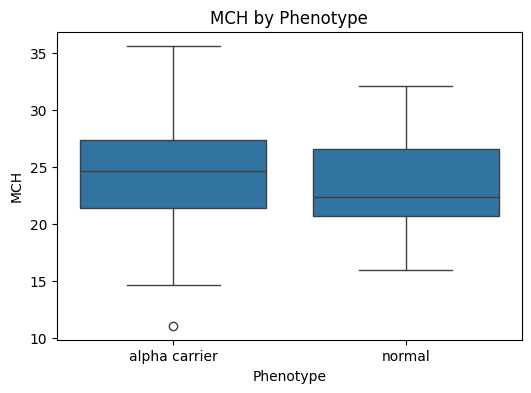

In [12]:
plt.figure(figsize=(6, 4))

sns.boxplot(x="phenotype", y="mch", data=data)

plt.title("MCH by Phenotype")
plt.xlabel("Phenotype")
plt.ylabel("MCH")

plt.show()

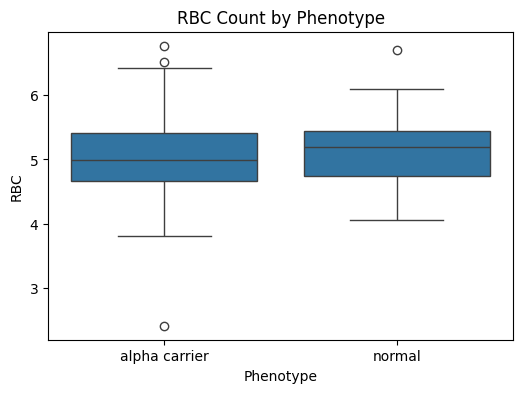

In [13]:
plt.figure(figsize=(6, 4))

sns.boxplot(x="phenotype", y="rbc", data=data)

plt.title("RBC Count by Phenotype")
plt.xlabel("Phenotype")
plt.ylabel("RBC")

plt.show()

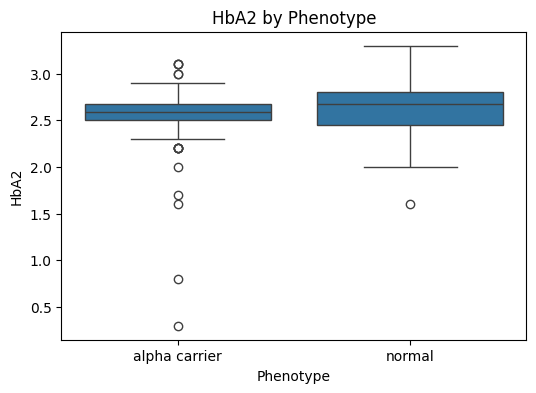

In [14]:
plt.figure(figsize=(6, 4))

sns.boxplot(x="phenotype", y="hba2", data=data)

plt.title("HbA2 by Phenotype")
plt.xlabel("Phenotype")
plt.ylabel("HbA2")

plt.show()

## 7. Preparing the Data for Machine Learning

We now separate the dataset into:

- Features (X): the blood measurements used to make the prediction
- Target (y): the phenotype we want to predict

The `phenotype` column will therefore be removed from the features.

In [15]:
X = data.drop("phenotype", axis=1)
y = data["phenotype"]

### Converting Sex into Numerical Values

The `sex` column contains categorical information.

We will convert it into numerical values so that it can be used by the model.

In [16]:
X["sex"] = X["sex"].map({"M": 0, "F": 1})

In [17]:
X.head()

,sex,hb,pcv,rbc,mcv,mch,mchc,rdw,wbc,neut,lymph,plt,hba,hba2,hbf
0,NaN,10.8,35.2,5.12,68.7,21.2,30.8,13.4,9.6,53.0,33.0,309.0,88.5,2.6,0.11
1,NaN,10.8,26.6,4.28,62.1,25.3,40.8,19.8,10.3,49.4,43.1,687.0,87.8,2.4,0.90
2,NaN,10.8,35.2,5.12,68.7,21.2,30.8,13.4,9.6,53.0,33.0,309.0,88.5,2.6,0.10
3,NaN,14.5,43.5,5.17,84.0,28.0,33.4,12.1,11.9,31.0,50.0,334.0,86.8,2.8,0.30
4,NaN,11.5,34.4,5.02,68.7,22.9,33.4,15.7,20.4,67.0,30.0,596.0,86.3,2.4,1.30


### Converting the Target Variable

The target contains two categories:

- normal
- alpha carrier

We will convert them into numbers:

- normal = 0
- alpha carrier = 1

In [18]:
y = y.map({
    "normal": 0,
    "alpha carrier": 1
})

In [19]:
y.value_counts()

,count
phenotype,
1,148
0,55


## 8. Splitting the Dataset

We divide the dataset into two parts:

- Training data: used to teach the model
- Testing data: used to see how well the model performs on unseen data

We will use 80% of the data for training and 20% for testing.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 9. Building the Machine Learning Model

We will use Logistic Regression.

Although its name contains the word "regression", Logistic Regression is commonly used for classification problems.

Our problem is a binary classification problem because there are only two possible outcomes:

- Normal
- Alpha carrier

Before training the model, we will scale the numerical features so that variables with different ranges can be compared fairly by the model.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## 10. Making Predictions

The trained model can now use the blood measurements from the test dataset to predict whether each individual is normal or an alpha-thalassemia carrier.

In [42]:
predictions = model.predict(X_test_scaled)
predictions

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## 11. Model Accuracy

Accuracy tells us the percentage of test observations that the model classified correctly.

In [43]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7073170731707317


## 12. Confusion Matrix

A confusion matrix gives us more information than accuracy alone.

It shows:

- True Negatives
- False Positives
- False Negatives
- True Positives

This is particularly useful for a classification problem because it allows us to see where the model is making mistakes.

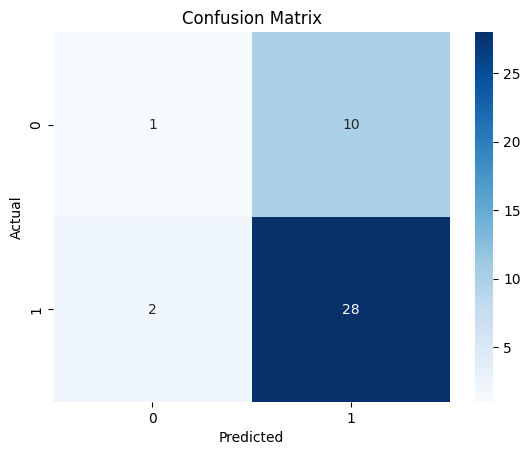

In [44]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## 13. Classification Report

We will also look at precision, recall and F1-score.

These measures help us understand the model's performance in more detail.

In [47]:
print(classification_report(
    y_test,
    predictions,
    target_names=["Normal", "Alpha Carrier"]
))

               precision    recall  f1-score   support

       Normal       0.33      0.09      0.14        11
Alpha Carrier       0.74      0.93      0.82        30

     accuracy                           0.71        41
    macro avg       0.54      0.51      0.48        41
 weighted avg       0.63      0.71      0.64        41



## 14. Understanding the Model

Logistic Regression gives us coefficients for each feature.

These coefficients indicate how each variable contributes to the prediction.

A positive coefficient pushes the prediction towards the alpha-carrier class, while a negative coefficient pushes it towards the normal class.

In [48]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
14,hbf,0.478967
4,mcv,0.451059
11,plt,0.141679
3,rbc,0.114017
5,mch,0.103526
12,hba,-0.002416
0,sex,-0.040184
8,wbc,-0.074148
2,pcv,-0.084794
1,hb,-0.227836


### Visualising Feature Coefficients

The following graph shows the direction and size of the Logistic Regression coefficients.

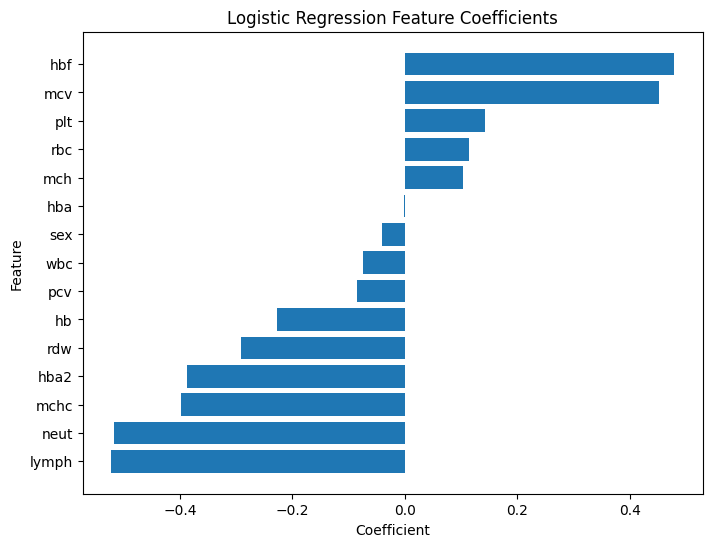

In [49]:
coefficients = coefficients.sort_values("Coefficient")

plt.figure(figsize=(8, 6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")

plt.show()

## 16. Testing the Model on a New Individual

We can also use the trained model to make a prediction for a new individual's blood-test measurements.

The example below is only for demonstrating how the model works.

In [51]:
new_person = pd.DataFrame({
    "sex": [0],
    "hb": [12.5],
    "pcv": [38],
    "rbc": [5.2],
    "mcv": [73],
    "mch": [24],
    "mchc": [33],
    "rdw": [14],
    "wbc": [7],
    "neut": [60],
    "lymph": [35],
    "plt": [250],
    "hba": [96],
    "hba2": [3],
    "hbf": [1]
})

# Scale the new person's measurements
new_person_scaled = scaler.transform(new_person)

# Make the prediction
result = model.predict(new_person_scaled)

if result[0] == 1:
    print("Predicted: Alpha Carrier")
else:
    print("Predicted: Normal")

Predicted: Alpha Carrier


## 15. Conclusion

In this project, we developed a simple machine learning model to differentiate between normal individuals and alpha-thalassemia carriers.

The project used full blood count and haemoglobin-variant measurements as input variables.

The main steps were:

1. Loaded and explored the dataset.
2. Checked and handled missing values.
3. Explored important blood measurements.
4. Prepared the features and target variable.
5. Split the data into training and testing sets.
6. Trained a Logistic Regression classification model.
7. Evaluated the model using accuracy, precision, recall, F1-score and a confusion matrix.
8. Examined the model coefficients to understand which variables contributed to the predictions.

The results show how machine learning can potentially be used as a screening-support approach for identifying alpha-thalassemia carrier status from routinely available blood measurements.

This model should not be considered a replacement for clinical diagnosis or confirmatory laboratory testing.